In [17]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import numpy as np

DATA_PATH = 'data'
# load the data
app_data = pd.read_csv(os.path.join(DATA_PATH, 'app_data_processed.csv'))

In [18]:
app_data.count()

SK_ID_CURR                     356255
TARGET                         307511
NAME_CONTRACT_TYPE             356255
FLAG_OWN_CAR                   356255
FLAG_OWN_REALTY                356255
                                ...  
INS_AMT_PAYMENT_SUM            339587
INS_DAYS_ENTRY_PAYMENT_MAX     339578
INS_DAYS_ENTRY_PAYMENT_MEAN    339578
INS_DAYS_ENTRY_PAYMENT_SUM     339587
INS_COUNT                      339587
Length: 525, dtype: int64

In [19]:
# 提取 TARGET 存在的行（这部分通常作为训练集 train_data）
train_data = app_data[app_data['TARGET'].notnull()].copy()

# 提取 TARGET 不存在的行（即为空值 NaN，这部分通常作为测试集 test_data）
test_data = app_data[app_data['TARGET'].isnull()].copy()

# 打印一下分离后的数据大小，确认是否分离成功
print(f"包含 TARGET 的数据（训练集）大小: {train_data.shape}")
print(f"不包含 TARGET 的数据（测试集）大小: {test_data.shape}")


包含 TARGET 的数据（训练集）大小: (307511, 525)
不包含 TARGET 的数据（测试集）大小: (48744, 525)


In [20]:
import re

# 将列名中所有不是字母、数字和下划线的字符全部替换成下划线
train_data = train_data.rename(columns = lambda x: re.sub('[^A-Za-z0-9_]+', '_', str(x)))


In [21]:
# 需要剔除的非特征 / 废特征列表
drop_columns = [
    'SK_ID_CURR', 
    'TARGET',
    'BU_SK_ID_BUREAU_MEAN',
    'BU_SK_ID_BUREAU_MAX',
    'BU_SK_ID_BUREAU_MIN',
    'BU_SK_ID_BUREAU_SUM'
]

# 假设你的完整数据叫 df
# 1. 提取标签
y = train_data['TARGET']

# 2. 剔除上述列，生成干净的特征矩阵 X
# errors='ignore' 可以防止列表中某些列由于测试集没有 TARGET 而报错
X = train_data.drop(columns=drop_columns, errors='ignore') 

print(f"清理完毕，最终用于训练的特征数量为: {X.shape[1]}")


清理完毕，最终用于训练的特征数量为: 519


In [47]:
def select_features_lgbm(X, y, top_n=100):
    """
    使用 LightGBM 评估特征重要性，绘制累计增益图，并返回筛选后的数据
    """
    print("正在使用 LightGBM 评估特征重要性...")
    
    # 1. 准备数据
    features = X.copy()
    target = y.copy()
    
    # 将字符串类型的列转换为 category 类型，LightGBM 才能识别
    for col in features.select_dtypes(include=['object']).columns:
        features[col] = features[col].astype('category')
        
    # 2. 训练一个浅层的 LightGBM 用于评估特征
    clf = lgb.LGBMClassifier(
        n_estimators=200, 
        max_depth=5, 
        learning_rate=0.05, 
        random_state=42, 
        n_jobs=-1
    )
    clf.fit(features, target)
    
    # 3. 提取特征重要性 (按信息增益 gain)
    importance_df = pd.DataFrame({
        'feature': features.columns,
        'importance': clf.booster_.feature_importance(importance_type='gain')
    }).sort_values('importance', ascending=False)

    # 4. 计算保留的信息量
    total_importance = importance_df['importance'].sum()
    importance_sum = []
    
    # 计算前 N 个特征的累计重要性
    for i in range(1, top_n + 1):
        top_n_importance = importance_df.head(i)['importance'].sum()
        importance_sum.append(top_n_importance)
        
    # 打印最终保留的比例
    retained_ratio = importance_sum[-1] / total_importance
    print(f"前 {top_n} 个特征保留了 {retained_ratio * 100:.2f}% 的总信息增益！")
    
    # 5. 画图展示：创建 1行2列 的画布，宽 16，高 6
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # ================== 子图 1：累计特征重要性 (双 Y 轴折线图) ==================
    color_raw, color_ratio = 'tab:blue', 'tab:red'
    
    # 1.1 绘制主 Y 轴 (原始 Gain)
    ax1.plot(range(1, top_n + 1), importance_sum, marker='o', color=color_raw, markersize=4)
    ax1.set_title(f'Top {top_n} Features Cumulative Importance')
    ax1.set_xlabel('Number of Top Features')
    ax1.set_ylabel('Cumulative Importance (Raw Gain)', color=color_raw)
    ax1.tick_params(axis='y', labelcolor=color_raw)
    ax1.grid(True)
    
    # 1.2 绘制副 Y 轴 (百分比)
    ax1_twin = ax1.twinx()
    ax1_twin.set_ylabel('Cumulative Ratio (%)', color=color_ratio)
    ax1_twin.tick_params(axis='y', labelcolor=color_ratio)
    y_min, y_max = ax1.get_ylim()
    ax1_twin.set_ylim(y_min / total_importance * 100, y_max / total_importance * 100)

    # ================== 子图 2：单特征重要性 (柱状图) ==================
    top_df = importance_df.head(top_n)
    
    ax2.bar(top_df['feature'], top_df['importance'], color='tab:blue', alpha=0.8)
    ax2.set_title(f'Top {top_n} Individual Features Importance')
    ax2.set_xlabel('Feature Name')
    ax2.set_ylabel('Importance (Gain)')
    
    # 将原来的 ax2.tick_params(axis='x', rotation=90) 替换为下面这行：
    ax2.set_xticks([]) # 彻底隐藏 X 轴的刻度和标签
    
    # ================== 渲染并展示 ==================
    fig.tight_layout() # 自动调整间距，防止文字被截断
    plt.show()         # 统一在最后调用 show()

    
    # 6. 组装返回最终的 DataFrame
    top_features = importance_df.head(top_n)['feature'].tolist()
    
    # 从原数据中提取精简后的特征
    df_selected = X[top_features].copy()
    # 把标签接回去
    df_selected['TARGET'] = target.values
    
    print(f"特征选择完成。原始特征数: {features.shape[1]}, 现有特征数: {top_n}")
    
    return df_selected


正在使用 LightGBM 评估特征重要性...
[LightGBM] [Info] Number of positive: 24825, number of negative: 282686
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.246027 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 51976
[LightGBM] [Info] Number of data points in the train set: 307511, number of used features: 510
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080729 -> initscore=-2.432486
[LightGBM] [Info] Start training from score -2.432486
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No fur

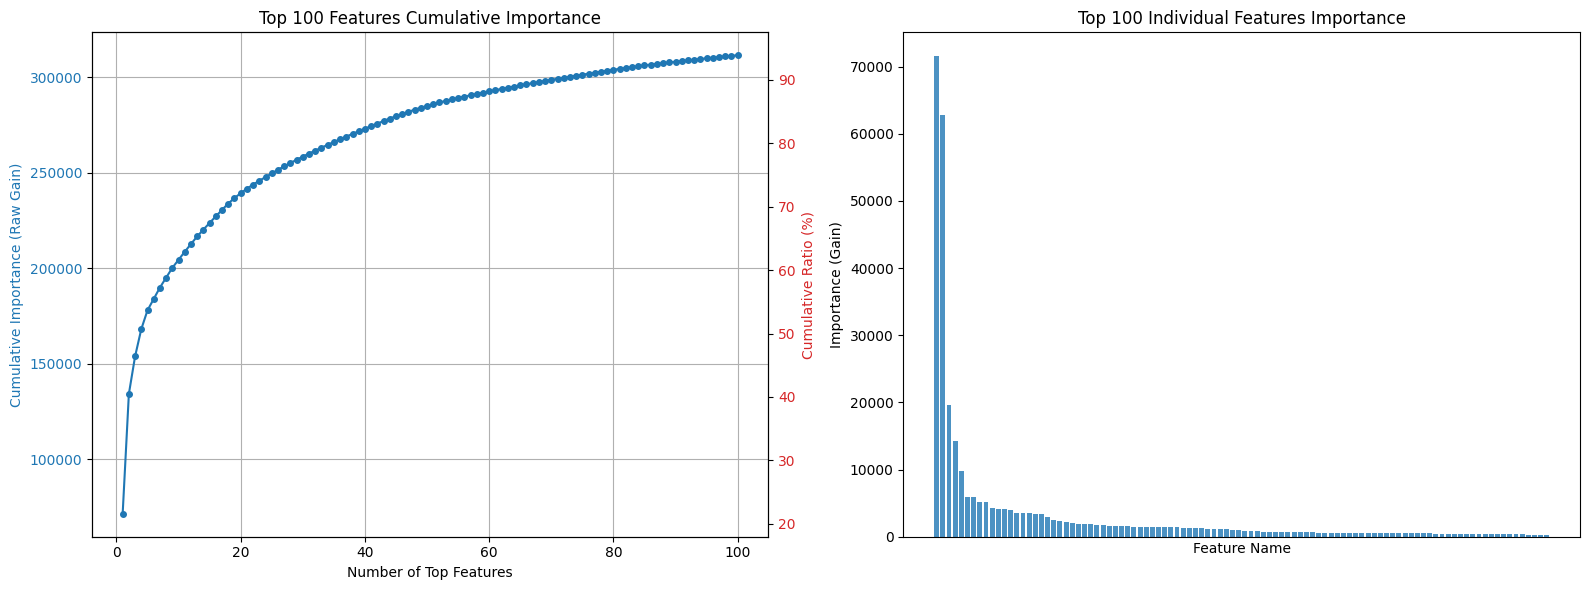

特征选择完成。原始特征数: 519, 现有特征数: 100


In [51]:
app_data_selected = select_features_lgbm(X, y, top_n=100)

In [ ]:
# 基于选择前300的结果，我们可以看到100个特征后，累计增益已经达到了一个比较高的水平（90%以上），说明这些特征已经包含了绝大部分的信息量。继续增加特征虽然会增加一些增益，但边际效应递减明显。因此，我们可以选择保留前100个特征，既能保证模型性能，又能大幅度减少特征数量，降低过拟合风险和计算成本。

In [53]:
app_data_selected.to_csv(os.path.join(DATA_PATH, 'app_data_selected.csv'), index=False)